🧪 Celda 1 – Imports básicos y autoreload

In [30]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

from image import FruitImage, FruitDataset
from kmeans import SimpleKMeans


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


🧪 Celda 2 – Definir la ruta del dataset y construir FruitDataset

In [31]:
# Ruta a la carpeta raíz con las subcarpetas de frutas
root_dir = "/home/bruno/fing/IA_I/img/"

ds = FruitDataset(root_dir)
ds.build(sat_threshold=40, central_fraction=0.6)

X, y = ds.get_data()

print("Shape X:", X.shape)  # (n_imágenes, 3)
print("Cantidad de muestras:", len(X))
print("Clases presentes:", np.unique(y))


Procesando clase: naranja
Procesando clase: manzana
Procesando clase: pera
Procesando clase: banana
Shape X: (4, 3)
Cantidad de muestras: 4
Clases presentes: ['banana' 'manzana' 'naranja' 'pera']
Procesando clase: banana
Shape X: (4, 3)
Cantidad de muestras: 4
Clases presentes: ['banana' 'manzana' 'naranja' 'pera']


🧪 Celda 3 – Funciones de ayuda para mostrar imágenes y máscaras

Estas funciones usan FruitImage para ver qué está pasando con una imagen puntual.

In [32]:
def show_bgr_image(bgr, title="BGR"):
    """Muestra una imagen BGR de OpenCV en matplotlib (RGB)."""
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    plt.imshow(rgb)
    plt.title(title)
    plt.axis("off")


def show_image_and_mask(img_path, sat_threshold=40, central_fraction=0.6):
    """Muestra la imagen original y la máscara de fruta."""
    fruit = FruitImage(img_path)
    mask = fruit.get_fruit_mask(sat_threshold=sat_threshold,
                                central_fraction=central_fraction)

    bgr = fruit.bgr
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    # Creamos una versión en color donde la fruta queda resaltada en rojo, por ejemplo
    mask_uint8 = mask.astype(np.uint8)
    # Para visualizar la máscara en rojo sobre la imagen:
    overlay = rgb.copy()
    overlay[mask] = [255, 0, 0]  # píxeles de fruta en rojo

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(rgb)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Máscara fruta")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Original + máscara")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


🧪 Celda 4 – Probar con una imagen concreta

Elegimos una imagen del dataset (por ejemplo la primera de la carpeta manzana) y miramos paso a paso.

Ejemplo: /home/bruno/fing/IA_I/img/naranja/narnaja_2.png  — etiqueta: naranja


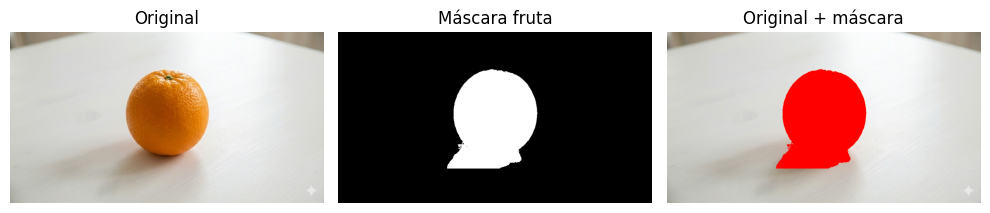

In [41]:
# Buscar una imagen de ejemplo
ejemplo_path = None

for label in os.listdir(root_dir):
    label_path = os.path.join(root_dir, label)
    if not os.path.isdir(label_path):
        continue
    for filename in os.listdir(label_path):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            ejemplo_path = os.path.join(label_path, filename)
            ejemplo_label = label
            break
    if ejemplo_path is not None:
        break

print("Ejemplo:", ejemplo_path, " — etiqueta:", ejemplo_label)

show_image_and_mask(ejemplo_path, sat_threshold=40, central_fraction=0.6)


🧪 Celda 5 – Ver el vector (H, S, V) de esa imagen de ejemplo

In [42]:
fruit = FruitImage(ejemplo_path)
h, s, v = fruit.get_dominant_hsv(sat_threshold=40, central_fraction=0.6)

print("Hue mediano:", h)
print("Sat mediana:", s)
print("Val mediana:", v)
print("Vector HSV:", [h, s, v])


Hue mediano: 14.0
Sat mediana: 244.0
Val mediana: 177.0
Vector HSV: [14.0, 244.0, 177.0]


🧪 Celda 6 – Entrenar SimpleKMeans con TODO el dataset

Acá vemos cómo se agrupan las frutas por color.

In [35]:
k = 4  # manzana, banana, pera, naranja
kmeans = SimpleKMeans(k=k, max_iters=100, tol=1e-4, random_state=42)
kmeans.fit(X)

print("Centroides encontrados (H, S, V):")
for i, c in enumerate(kmeans.centroids):
    print(f"Cluster {i}: {c}")


Centroides encontrados (H, S, V):
Cluster 0: [ 14. 166. 117.]
Cluster 1: [ 22. 159. 192.]
Cluster 2: [ 14. 244. 177.]
Cluster 3: [ 27. 190. 135.]


🧪 Celda 7 – Ver a qué cluster va cada imagen


In [36]:
labels = kmeans.predict(X)

for i in range(min(10, len(X))):
    print(f"i={i:02d} | vec={X[i]} | etiqueta_real={y[i]} | cluster={labels[i]}")


i=00 | vec=[ 14. 244. 177.] | etiqueta_real=naranja | cluster=2
i=01 | vec=[ 14. 166. 117.] | etiqueta_real=manzana | cluster=0
i=02 | vec=[ 27. 190. 135.] | etiqueta_real=pera | cluster=3
i=03 | vec=[ 22. 159. 192.] | etiqueta_real=banana | cluster=1


🧪 Celda 8 – Ver cómo se separan en el espacio de Hue (gráfico rápido)

Solo para intuición: graficamos Hue vs índice, coloreado por clase real y por cluster.

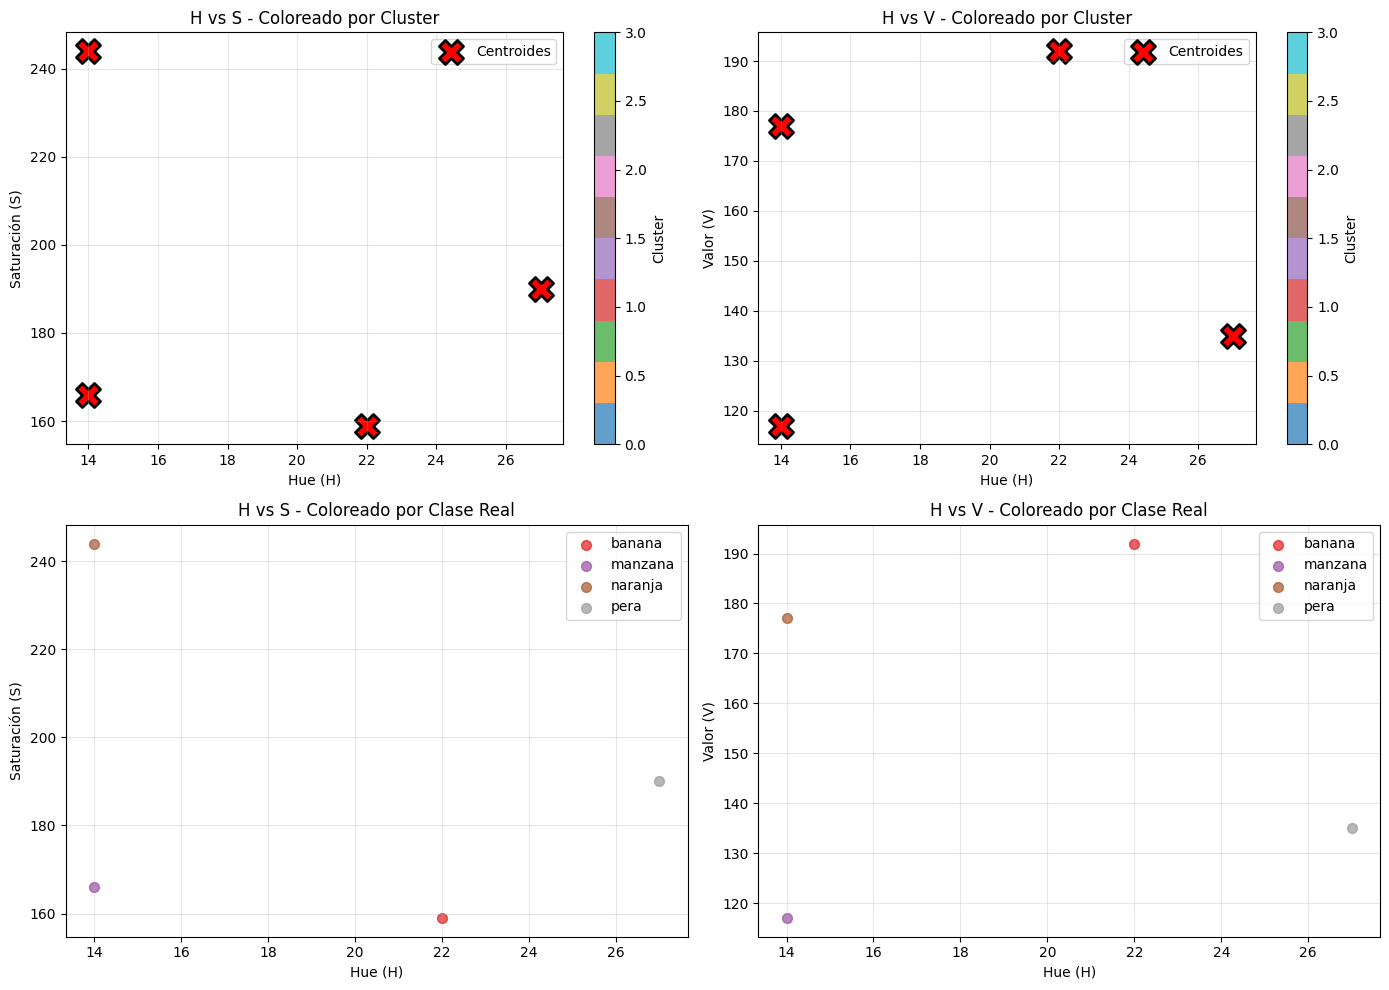


Reporte de clustering:
Total de imágenes: 4
Cantidad de clusters: 4
  Cluster 0: 1 imágenes
  Cluster 1: 1 imágenes
  Cluster 2: 1 imágenes
  Cluster 3: 1 imágenes


In [37]:
plt.figure(figsize=(10, 4))
plt.scatter(range(len(X)), X[:, 0], c=labels, cmap="tab10")
plt.colorbar(label="Cluster")
plt.xlabel("Índice de imagen")
plt.ylabel("Hue (H)")
plt.title("Hue de cada imagen y cluster asignado")
plt.show()


ModuleNotFoundError: No module named 'sklearn'

ModuleNotFoundError: No module named 'sklearn'

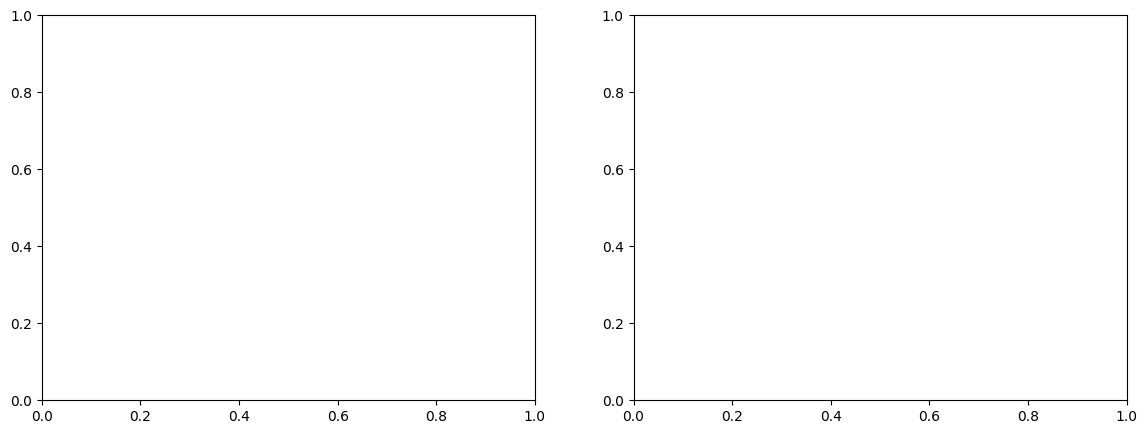

In [38]:
unique_labels = np.unique(y)

plt.figure(figsize=(10, 4))
for fruta in unique_labels:
    idx = np.where(y == fruta)[0]
    plt.scatter(idx, X[idx, 0], label=fruta)
plt.xlabel("Índice de imagen")
plt.ylabel("Hue (H)")
plt.title("Hue por tipo de fruta")
plt.legend()
plt.show()
